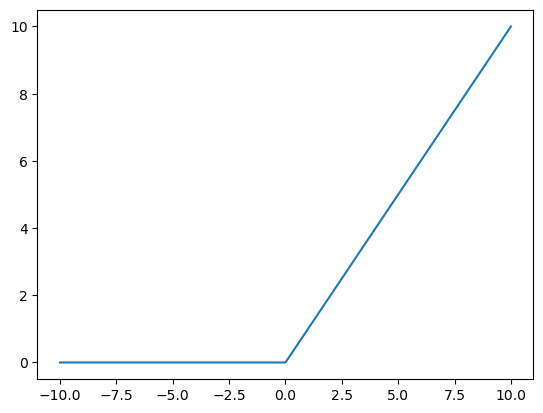

In [1]:
# sigmoid 
# relu
import matplotlib.pyplot as plt
import numpy as np

def relu(x):
    # 0과 x를 비교해서 큰값을 반환
    return np.maximum(0,x)

# -10 ~ 10 사이의 숫자 400개 순차적으로 생성
x = np.linspace(-10, 10, 400)
y = relu(x)

plt.plot(x, y)
plt.show()

In [2]:
import numpy as np

x = np.array([ [1,1], [1,0], [0,1], [0,0] ])
y = np.array([ [0], [1], [1], [0] ])

# (n, 2) => (n, 1) => sigmoid
x.shape, y.shape

((4, 2), (4, 1))

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(2,)),
    Dense(units=16, activation="relu"),
    Dense(units=1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])


In [12]:
model.fit(x, y, epochs=1000, verbose=2)

Epoch 1/1000
1/1 - 0s - 29ms/step - accuracy: 1.0000 - loss: 0.0191
Epoch 2/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0191
Epoch 3/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 4/1000
1/1 - 0s - 30ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 5/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 6/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 7/1000
1/1 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 8/1000
1/1 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 9/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 10/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0190
Epoch 11/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0189
Epoch 12/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0189
Epoch 13/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0189
Epoch 14/1000
1/1 - 0s - 35ms/step - accuracy: 1.0000 - loss: 0.0189
Epoch 15/1000
1/1 - 0s - 36ms/step - accura

In [13]:
pred = model.predict(x)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[0.00148038],
       [0.99833596],
       [0.9973968 ],
       [0.03590518]], dtype=float32)

In [16]:
# 다른 방식
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

inputs = Input(shape=(2, ))
hidden = Dense(units=16, activation="relu")(inputs)
outputs = Dense(units=1, activation="sigmoid")(hidden)

model = Model(inputs, outputs)
hidden_model = Model(inputs, hidden)

hidden_output = hidden_model.predict(x)
print(hidden_output.shape)
print(hidden_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(4, 16)
[[0.40362346 0.         0.08461738 0.35195112 0.         0.51530135
  0.6242057  0.6384267  0.14481398 0.         0.         0.37891984
  0.         0.         0.17678767 0.02396876]
 [0.4656204  0.         0.         0.         0.         0.45175958
  0.42744195 0.11103636 0.36933327 0.05942863 0.14899194 0.
  0.38487804 0.         0.16166121 0.37252772]
 [0.         0.         0.40417987 0.5676701  0.         0.06354177
  0.19676375 0.52739036 0.         0.         0.         0.39375752
  0.         0.         0.01512647 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]]


In [18]:
import pandas as pd
df = pd.read_csv("http://114.207.245.181:13000/csv/Advertising.csv")
df

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [19]:
df.columns

Index(['ID', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [21]:
t1 = {'Radio':'라디오', 'Newspaper':'신문', 'Sales':'판매'}
df.rename(columns=t1, inplace=True)

In [23]:
df.dtypes

ID       int64
TV     float64
라디오    float64
신문     float64
판매     float64
dtype: object

In [40]:
x = df[['TV', '라디오', '신문']].values
y = df[['판매']].values
x.shape, y.shape

((200, 3), (200, 1))

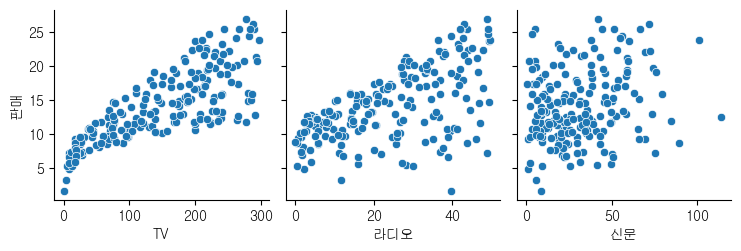

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc('font', family='Gulim')

sns.pairplot(df, x_vars=['TV','라디오','신문'], y_vars=['판매'])
plt.show()

In [42]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=123)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 3), (40, 3), (160, 1), (40, 1))

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((160, 3), (40, 3))

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(3, )),
    Dense(units=12, activation="relu"),
    Dense(units=1, activation="linear")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

# adam 기본 learning_rate 값 0.001
optimizer = Adam(learning_rate=0.0005)
# mse 오차제곱평균 => 큰 오차를 강하게 줄임
# mae 오차절대값평균 => 평가지표로 사용
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

In [60]:
history = model.fit(x_train_scaled, y_train, epochs=1000, validation_data=(x_test_scaled, y_test), verbose=2)


Epoch 1/1000
5/5 - 0s - 16ms/step - loss: 0.9080 - mae: 0.6378 - val_loss: 0.8011 - val_mae: 0.6956
Epoch 2/1000
5/5 - 0s - 13ms/step - loss: 0.9057 - mae: 0.6372 - val_loss: 0.8000 - val_mae: 0.6950
Epoch 3/1000
5/5 - 0s - 13ms/step - loss: 0.9032 - mae: 0.6363 - val_loss: 0.7975 - val_mae: 0.6942
Epoch 4/1000
5/5 - 0s - 13ms/step - loss: 0.9008 - mae: 0.6352 - val_loss: 0.7954 - val_mae: 0.6932
Epoch 5/1000
5/5 - 0s - 13ms/step - loss: 0.8989 - mae: 0.6345 - val_loss: 0.7931 - val_mae: 0.6922
Epoch 6/1000
5/5 - 0s - 13ms/step - loss: 0.8970 - mae: 0.6338 - val_loss: 0.7905 - val_mae: 0.6912
Epoch 7/1000
5/5 - 0s - 13ms/step - loss: 0.8946 - mae: 0.6327 - val_loss: 0.7875 - val_mae: 0.6901
Epoch 8/1000
5/5 - 0s - 13ms/step - loss: 0.8926 - mae: 0.6320 - val_loss: 0.7872 - val_mae: 0.6901
Epoch 9/1000
5/5 - 0s - 13ms/step - loss: 0.8904 - mae: 0.6315 - val_loss: 0.7862 - val_mae: 0.6898
Epoch 10/1000
5/5 - 0s - 14ms/step - loss: 0.8885 - mae: 0.6307 - val_loss: 0.7834 - val_mae: 0.6886

In [61]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

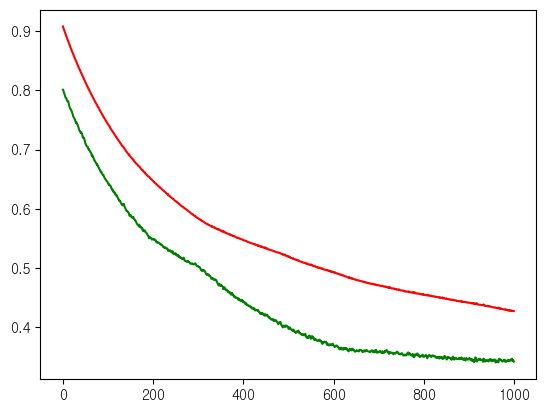

In [62]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', family='Gulim')

plt.plot(history.history['loss'], c='r')
plt.plot(history.history['val_loss'], c='g')
plt.show()

In [63]:
y_pred = model.predict(x_test_scaled)
y_pred[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[11.337963],
       [ 8.54365 ],
       [14.522165],
       [ 8.780045],
       [15.099152]], dtype=float32)

In [64]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.988950772580503

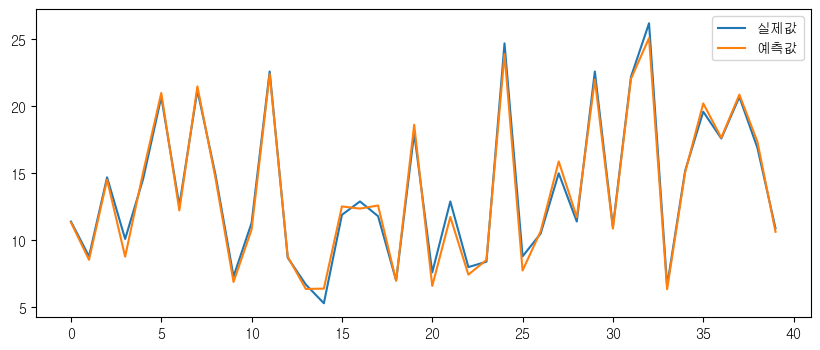

In [65]:
import matplotlib.pyplot as plt
plt.rc('font', family='Gulim')

plt.figure(figsize=(10, 4))
plt.plot(y_test, label="실제값")
plt.plot(y_pred, label="예측값")
plt.legend()
plt.show()

In [66]:
# 스케일러 + 모델 저장
import joblib
joblib.dump(scaler,"./pkl/20260529_scaler.pkl")
model.save('./pkl/20260529_model.keras')

In [67]:
# 모델 읽기
from tensorflow.keras.models import load_model
import joblib

scaler = joblib.load("./pkl/20260529_scaler.pkl")
model = load_model('./pkl/20260529_model.keras')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (744.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 124 (500.00 B)